In [11]:
# Import Libraries
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
print("Numpy", np.__version__)
print("Pandas", pd.__version__)
print("Sklearn", sklearn.__version__)


Numpy 2.0.2
Pandas 2.2.2
Sklearn 1.6.1


In [2]:
# Load Dataset

data = pd.read_csv("/content/drive/MyDrive/HIT_Project/heart.csv")
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [3]:
print("Dataset Shape:", data.shape)
print("\nMissing Values:\n", data.isnull().sum())


Dataset Shape: (1025, 14)

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [4]:
# Split Features and Target
X = data.drop("target", axis=1)
y = data["target"]

print("Feature Shape:", X.shape)

Feature Shape: (1025, 13)


In [5]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Train Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [7]:
import joblib

joblib.dump(model, "heart_disease_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
# Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9853658536585366

Confusion Matrix:
[[102   0]
 [  3 100]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



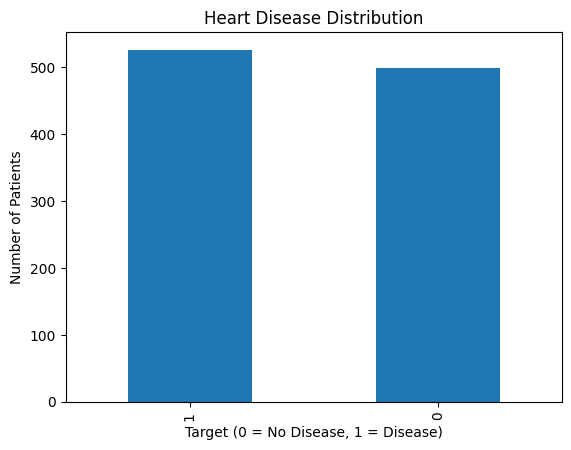

In [ ]:
plt.figure()
data["target"].value_counts().plot(kind="bar")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Distribution")
plt.show()

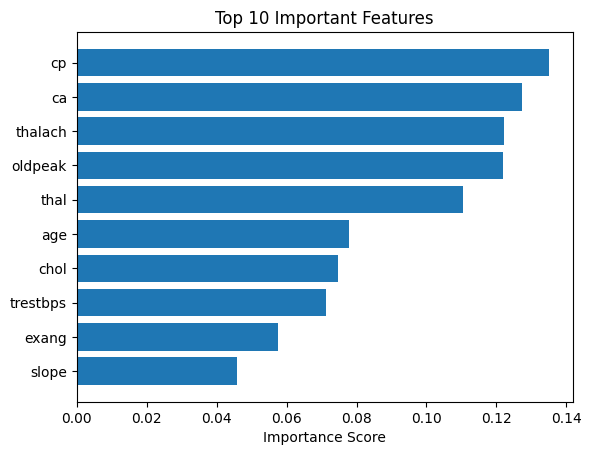

In [ ]:
# Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.xlabel("Importance Score")
plt.title("Top 10 Important Features")
plt.show()

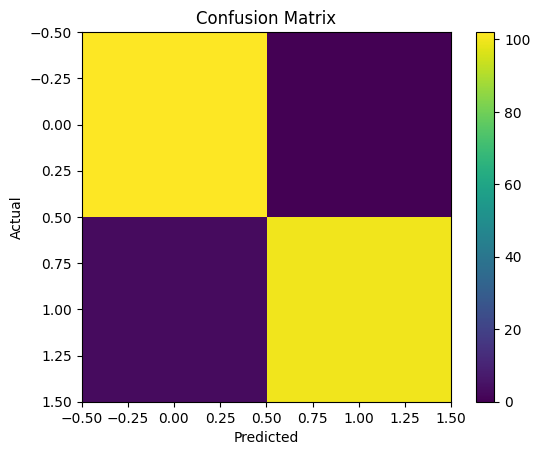

In [ ]:
# Confusion Matrix Graph
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Predict a New Patient
new_patient = {
    'age': 63,
    'sex': 1,
    'cp': 3,
    'trestbps': 145,
    'chol': 233,
    'fbs': 1,
    'restecg': 0,
    'thalach': 150,
    'exang': 0,
    'oldpeak': 2.3,
    'slope': 0,
    'ca': 0,
    'thal': 1
}

input_df = pd.DataFrame([new_patient])

prediction = model.predict(input_df)
probability = model.predict_proba(input_df)

if prediction[0] == 1:
    print("The person has Heart Disease")
else:
    print("The person does NOT have Heart Disease")

print("Probability [No Disease, Disease]:", probability)


The person has Heart Disease
Probability [No Disease, Disease]: [[0.03 0.97]]


In [9]:
ls

drive/  heart_disease_model.pkl  sample_data/


In [10]:
from google.colab import files
files.download("heart_disease_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>